In [3]:
from google.colab import files

# This will open a file picker where you can select your CSV file.
# Once uploaded, the file will be available in the Colab environment.
uploaded = files.upload()

Saving Dataset 2.csv to Dataset 2.csv


In [5]:
#Question1
import pandas as pd

# NumPy helps with numerical computations
import numpy as np
df = pd.read_csv('Dataset 2.csv')

# Display first 5 rows
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [7]:
#Question2 determine the number of rows and columns in the dataset
print("rows: ")
print(df.shape[0])
print("columns: ")
print(df.shape[1])

rows: 
750
columns: 
10


In [9]:
#Question3 Display all column names.
print("columns:")
print(df.columns)

columns:
Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')


In [10]:
#Question4 Identify numerical and categorical features.
print("numerical features:")
print(df.select_dtypes(include=[np.number]).columns)
print("categorical features:")
print(df.select_dtypes(include=['object']).columns)

numerical features:
Index(['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks',
       'MonthlySpend'],
      dtype='object')
categorical features:
Index(['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed'], dtype='object')


In [11]:
#Question5 Check whether the dataset contains missing values.
print(df.isnull().sum())

UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64


In [12]:
#Question6 Calculate the average age of users.
print("average age:")
print(df.Age.mean())

average age:
41.824


In [14]:
#Question7 Determine the average watch hours per week.
print("average watch hours per week:")
print(df.WatchHoursPerWeek.mean())

average watch hours per week:
14.236


In [15]:
#Question8 Find the average monthly spending of users.
print("average monthly spending:")
print(df.MonthlySpend.mean())

average monthly spending:
689.9053333333334


In [18]:
#Question9 Count the number of users in each subscription category.
print(df.SubscriptionType.value_counts())

SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


In [22]:
#Question10 Determine the percentage of users who renewed their subscriptions.
print(df.SubscriptionRenewed.value_counts(normalize=True)*100)

SubscriptionRenewed
No     53.733333
Yes    46.266667
Name: proportion, dtype: float64


In [23]:
#Question11 Convert categorical features into numerical form.
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding using pd.get_dummies()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Original DataFrame columns:", df.columns.tolist())
print("Encoded DataFrame columns:", df_encoded.columns.tolist())
display(df_encoded.head())

Original DataFrame columns: ['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend', 'SubscriptionRenewed']
Encoded DataFrame columns: ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend', 'Gender_Male', 'SubscriptionType_Premium', 'SubscriptionType_VIP', 'FavoriteGenre_Comedy', 'FavoriteGenre_Drama', 'FavoriteGenre_Horror', 'FavoriteGenre_Romance', 'FavoriteGenre_Sci-Fi', 'SubscriptionRenewed_Yes']


,UserID,Age,WatchHoursPerWeek,DevicesUsed,AdClicks,MonthlySpend,Gender_Male,SubscriptionType_Premium,SubscriptionType_VIP,FavoriteGenre_Comedy,FavoriteGenre_Drama,FavoriteGenre_Horror,FavoriteGenre_Romance,FavoriteGenre_Sci-Fi,SubscriptionRenewed_Yes
0,1001,22,23,5,13,353,False,False,False,True,False,False,False,False,False
1,1002,55,9,4,14,317,True,False,False,False,True,False,False,False,True
2,1003,49,8,3,16,309,True,False,False,True,False,False,False,False,False
3,1004,39,19,5,45,833,False,True,False,False,True,False,False,False,True
4,1005,38,23,5,24,804,False,True,False,False,False,False,False,True,True


In [25]:
#Question12 Define the feature set (X) and target variable (y) for subscription renewal prediction.

# Define the target variable (y)
y = df_encoded['SubscriptionRenewed_Yes']

# Define the feature set (X) by dropping the target and UserID
X = df_encoded.drop(columns=['SubscriptionRenewed_Yes', 'UserID'])

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFeatures (X) head:")
display(X.head())

print("\nTarget (y) head:")
display(y.head())

Shape of X: (750, 13)
Shape of y: (750,)

Features (X) head:


,Age,WatchHoursPerWeek,DevicesUsed,AdClicks,MonthlySpend,Gender_Male,SubscriptionType_Premium,SubscriptionType_VIP,FavoriteGenre_Comedy,FavoriteGenre_Drama,FavoriteGenre_Horror,FavoriteGenre_Romance,FavoriteGenre_Sci-Fi
0,22,23,5,13,353,False,False,False,True,False,False,False,False
1,55,9,4,14,317,True,False,False,False,True,False,False,False
2,49,8,3,16,309,True,False,False,True,False,False,False,False
3,39,19,5,45,833,False,True,False,False,True,False,False,False
4,38,23,5,24,804,False,True,False,False,False,False,False,True



Target (y) head:


,SubscriptionRenewed_Yes
0,False
1,True
2,False
3,True
4,True


In [27]:
#Question13 Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (600, 13)
Shape of X_test: (150, 13)
Shape of y_train: (600,)
Shape of y_test: (150,)


In [31]:
#Question14 Train a Decision Tree model to predict whether a user will renew their subscription.
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [32]:
#Question15 Evaluate the model using accuracy.
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.5267


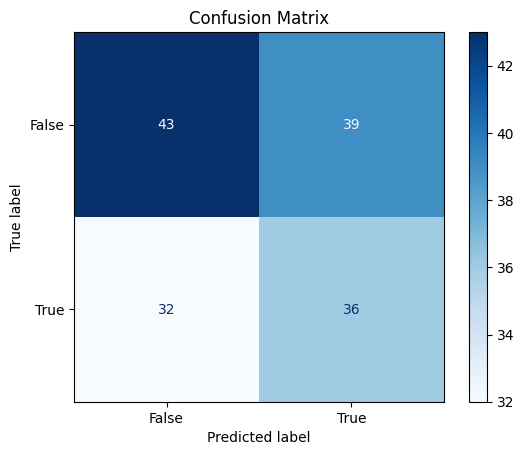

In [34]:
#Question16 Generate and interpret the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set (re-added for robustness)
y_pred = dtc.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtc.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [36]:
#Question17 Train a KNN classifier with K = 5.
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier with K=5
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
knn_classifier.fit(X_train, y_train)

print("KNN classifier with K=5 trained successfully.")

KNN classifier with K=5 trained successfully.


In [38]:
#Question 18
# Make predictions on the test set using the KNN classifier
y_pred_knn = knn_classifier.predict(X_test)

# Calculate the accuracy for the KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN Model Accuracy: {accuracy_knn:.4f}")

KNN Model Accuracy: 0.6333


In [39]:
#Question19 Prepare data for Linear Regression

# Define the target variable for monthly spending
y_lr = df_encoded['MonthlySpend']

# Define the feature set for monthly spending prediction.
# Exclude 'UserID' and 'SubscriptionRenewed_Yes' (as it's a classification target)
# and 'MonthlySpend' itself.
X_lr = df_encoded.drop(columns=['UserID', 'MonthlySpend', 'SubscriptionRenewed_Yes'])

print("Shape of X_lr:", X_lr.shape)
print("Shape of y_lr:", y_lr.shape)

print("\nFeatures (X_lr) head:")
display(X_lr.head())

print("\nTarget (y_lr) head:")
display(y_lr.head())

Shape of X_lr: (750, 12)
Shape of y_lr: (750,)

Features (X_lr) head:


,Age,WatchHoursPerWeek,DevicesUsed,AdClicks,Gender_Male,SubscriptionType_Premium,SubscriptionType_VIP,FavoriteGenre_Comedy,FavoriteGenre_Drama,FavoriteGenre_Horror,FavoriteGenre_Romance,FavoriteGenre_Sci-Fi
0,22,23,5,13,False,False,False,True,False,False,False,False
1,55,9,4,14,True,False,False,False,True,False,False,False
2,49,8,3,16,True,False,False,True,False,False,False,False
3,39,19,5,45,False,True,False,False,True,False,False,False
4,38,23,5,24,False,True,False,False,False,False,False,True



Target (y_lr) head:


,MonthlySpend
0,353
1,317
2,309
3,833
4,804


In [40]:
# Split the data into training and testing sets for Linear Regression
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

print("Shape of X_train_lr:", X_train_lr.shape)
print("Shape of X_test_lr:", X_test_lr.shape)
print("Shape of y_train_lr:", y_train_lr.shape)
print("Shape of y_test_lr:", y_test_lr.shape)

Shape of X_train_lr: (600, 12)
Shape of X_test_lr: (150, 12)
Shape of y_train_lr: (600,)
Shape of y_test_lr: (150,)


In [41]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_lr, y_train_lr)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [42]:
#Q20. Predict the monthly spending for a new user and interpret the result.

# Create a hypothetical new user with features similar to the training data.
# The order of features must match X_lr.columns
# Example values:
# 'Age': 30
# 'WatchHoursPerWeek': 15
# 'DevicesUsed': 3
# 'AdClicks': 20
# 'Gender_Male': 0 (Female)
# 'SubscriptionType_Premium': 1 (Premium)
# 'SubscriptionType_VIP': 0
# 'FavoriteGenre_Comedy': 0
# 'FavoriteGenre_Drama': 1 (Drama)
# 'FavoriteGenre_Horror': 0
# 'FavoriteGenre_Romance': 0
# 'FavoriteGenre_Sci-Fi': 0

# Example: A 30-year-old female, watching 15 hours/week on 3 devices, 20 ad clicks,
# with a Premium subscription, and favorite genre Drama.
new_user_data = {
    'Age': [30],
    'WatchHoursPerWeek': [15],
    'DevicesUsed': [3],
    'AdClicks': [20],
    'Gender_Male': [0],
    'SubscriptionType_Premium': [1],
    'SubscriptionType_VIP': [0],
    'FavoriteGenre_Comedy': [0],
    'FavoriteGenre_Drama': [1],
    'FavoriteGenre_Horror': [0],
    'FavoriteGenre_Romance': [0],
    'FavoriteGenre_Sci-Fi': [0]
}

new_user_df = pd.DataFrame(new_user_data, columns=X_lr.columns)

# Predict monthly spending for the new user
predicted_spend = linear_model.predict(new_user_df)

print(f"Predicted Monthly Spending for the new user: ${predicted_spend[0]:.2f}")

Predicted Monthly Spending for the new user: $765.94
